# Barcelona Traffic Accidents: Geospatial & Administrative Safety Profiling
This notebook shifts our analytical focus from temporal trends to spatial dimensions. By evaluating traffic incident distributions across Barcelona's 10 Districts, 73 Neighborhoods (Barris), and key transit streets, we aim to uncover structural localized hot spots and safety anomalies.

### Core Metrics Tracked:
1. **Absolute Crash Footprint**: Total counts of incidents across locations.
2. **Severity Concentration (`target`)**: The mean rate of severe injuries or fatalities per location.
3. **Casualty Magnitude**: Average number of injured or deceased individuals per incident.

***NOTE: accidents and victims are highly correlated therefore I will limit the analysis to num_accidents and target***

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import python_files.functions_barcelona as fb
import python_files.paths_mapping as pm
import python_files.functions_plotting as fp

import geopandas as gpd
import folium
import geopy
import geocoder
import osmnx
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter



# Set visual preferences
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


def mapping_street_codes(row):
    split_code = row['id_intersection'].split('-')
    first = street_mapper[int(split_code[0])]
    second = street_mapper.get(int(split_code[1]),'NO_CROSSING')
    return first + ' / '+ second


In [2]:
year = 2025
accidents = pd.read_csv(pm.FILES_PATH / f'accidents_weather{year}.csv',parse_dates=['datetime'])
street_mapper = pd.read_csv(fb.FILES_PATH / 'carrerer.csv')[['codi_via','nom_oficial']].set_index('codi_via').to_dict()['nom_oficial']
cleaned_streets = pd.read_csv(pm.FILES_PATH / f'cleaned_streets_{year}.csv')
cleaned_streets['raw_location'] = cleaned_streets['raw_location'].str.lower()
cleaned_streets =  cleaned_streets.drop_duplicates()
cleaned_streets.loc[(cleaned_streets.location_type == 'Single Street'), 'official_name_2'] = 'NO CROSSING'
cleaned_streets.fillna({'code_via_2': 999999},inplace=True)
if accidents.isnull().sum().sum() != 0:
    print(accidents.isnull().sum()[accidents.isnull().sum()>0].index)
if cleaned_streets.isnull().sum().sum() != 0:
    print(cleaned_streets.isnull().sum()[cleaned_streets.isnull().sum()>0].index)

accidents['is_severe'] = ((accidents['num_deaths'] + accidents['num_severly_injured'])>0).astype(int)
int_columns =['hour', 'is_severe','num_deaths','num_victims']
for col in int_columns:
    accidents[col] =accidents[col].astype(int)
accidents['weekday'] = accidents['weekday'].str[:3]
accidents['month'] = accidents['month'].str[:3]
accidents['street_name'] = accidents['street_name'].str.lower().str.strip()
accidents['num_incident'] = accidents['num_incident'].str.strip()
# print(accidents.district.value_counts())
# accidents.columns
#mergin with cleaned_streets
previous_rows = accidents.shape[0]
accidents = pd.merge(accidents,cleaned_streets[['code_via_1',
                                                'official_name_1',
                                                'code_via_2',
                                                'official_name_2',
                                                'location_type',
                                                'raw_location']],
         left_on = 'street_name',
         right_on ='raw_location',
         how='left')
# print("JOINED: ", cleaned_acc.shape,'/n',"ACC: ", accidents.shape,'/n', cleaned_streets.shape)
assert previous_rows == accidents.shape[0], "Something weird happened with the join"
assert accidents.isnull().sum().sum() == 0 , "Creating Nulls"
street_codes = pd.read_csv(pm.FILES_PATH / 'street_codes.csv')
accidents = accidents.merge(street_codes,on ='num_incident', how='left')
accidents['street_code'] = accidents['street_code'].astype(int)
assert accidents.isnull().sum().sum() == 0 ,'Problems merging street codes'
sorted_codes = np.sort(accidents[['code_via_1', 'code_via_2']].values, axis=1)
accidents['id_intersection'] = [f"{int(row[0])}-{int(row[1])}" for row in sorted_codes]
accidents['intersection_name'] = accidents.apply(mapping_street_codes,axis = 1)
bordering_towns = ['Esplugues de Llobregat', "l'Hospitalet de Llobregat"]
accidents = accidents[~accidents.district.isin(bordering_towns)]

## 1. **District Analysis — Volume vs. Severity Rate**

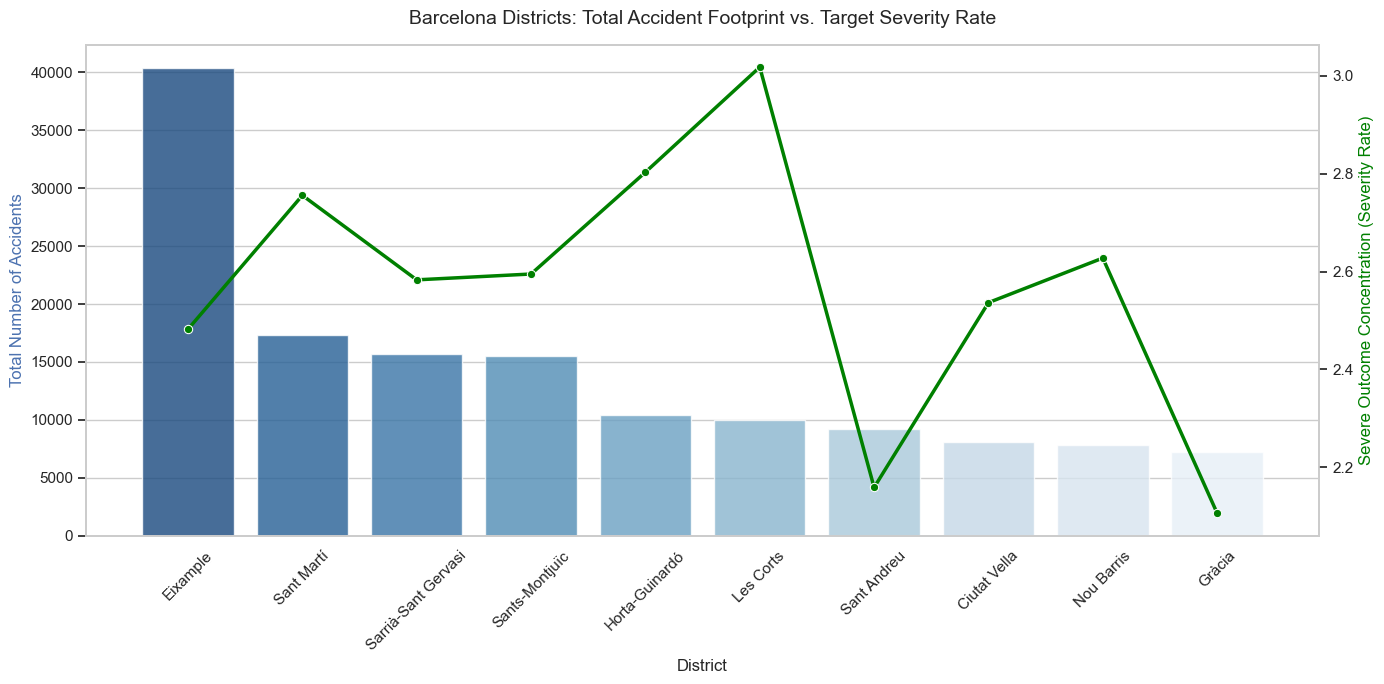

In [4]:
# Aggregate data by District
district_stats = accidents.groupby('district').agg(
    total_accidents=('num_incident', 'count'),
    total_deaths=('num_deaths','sum'),
    severity_rate=('is_severe', 'mean'),
    
).sort_values(by='total_accidents', ascending=False).reset_index()
district_stats['severity_rate'] = district_stats['severity_rate'] *100

fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary Axis: Absolute Volume Bar Chart
sns.barplot(data=district_stats, x='district',
            y='total_accidents',
            ax=ax1,
            hue ='district',
            alpha=0.8, 
            errorbar=None, 
            palette ='Blues_r')
ax1.set_title('Barcelona Districts: Total Accident Footprint vs. Target Severity Rate', pad=15)
ax1.set_xlabel('District')
ax1.set_ylabel('Total Number of Accidents', color='b')
ax1.tick_params(axis='x', rotation=45)


# Secondary Axis: Severity Rate Line Chart
ax2 = ax1.twinx()
sns.lineplot(data=district_stats, x='district', y='severity_rate', ax=ax2, color='green', marker='o', linewidth=2.5, sort=False)
ax2.set_ylabel('Severe Outcome Concentration (Severity Rate)', color='green')
ax2.grid(False)
plt.tight_layout()
plt.show()

> Eixample is the district with most accidents, deaths (and victims) but is Les Corts the district with the highest target mean.


In [5]:
#Curious to know the top neighborhoods in these districts? Les Corts, Horta-Guinardo and Sant Marti
top_districts = district_stats.sort_values('severity_rate',ascending=False).iloc[0:3]['district'].tolist()
accidents[accidents.district.isin(top_districts)].groupby(['neighborhood','district'])[['is_severe']].mean().sort_values('is_severe',ascending=False).iloc[:5]

,,is_severe
neighborhood,district,
Provençals del Poblenou,Sant Martí,0.042535
Can Baró,Horta-Guinardó,0.036765
el Baix Guinardó,Horta-Guinardó,0.036210
la Maternitat i Sant Ramon,Les Corts,0.031851
el Guinardó,Horta-Guinardó,0.031585


[Go back top](##Plotting:-TIME-BASED-FEATURES)


## 2. **Neighborhood Analysis — The Risk Quadrant Matrix**

> Going over the neighborhoods, classify the neighborhoods based in the average number of accidents an average of severity.
> 1. Q1. High Volume-High Severity. Average volume over 75% of the average volume and 90% of severity average
> 2. Q2. High Volume-Low Severity.  Average volume over 75%
> 3. Q3. Low Volume-High Severyty. Average Severity over 90%.
> 4. Q4. Low Volume-Low Severity. The rest.

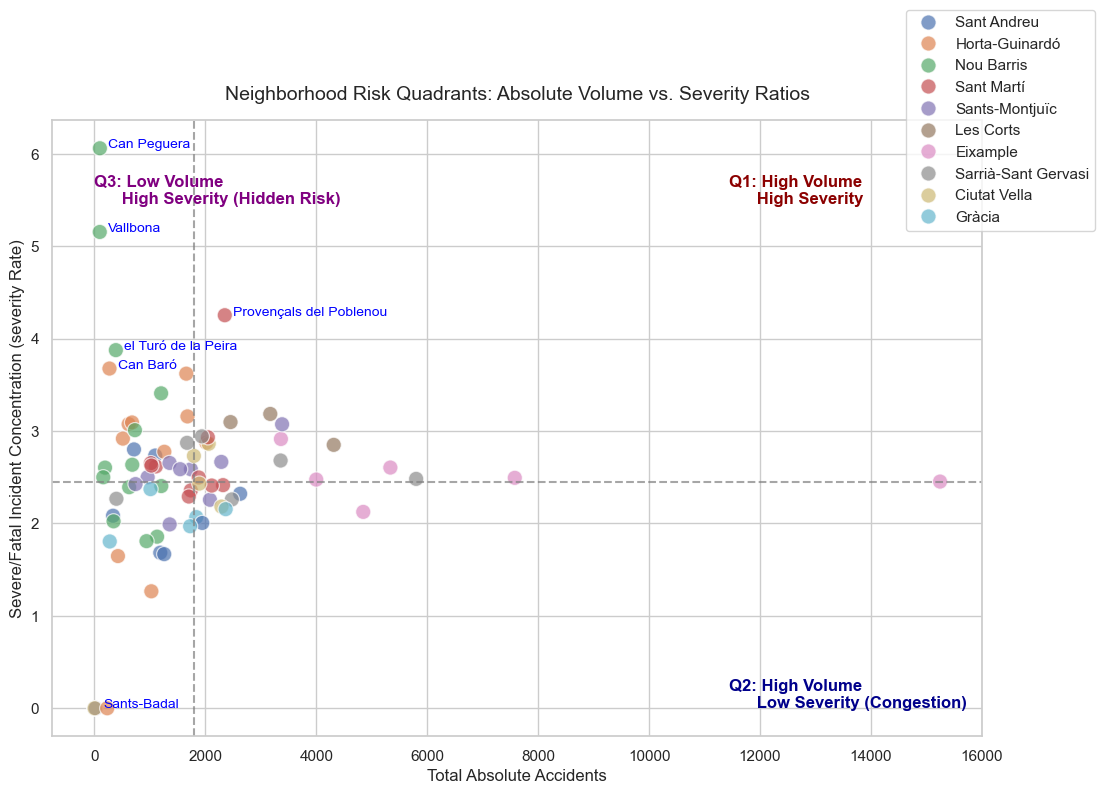

In [6]:
# Aggregate data by Neighborhood
neigh_stats = accidents.groupby(['neighborhood','district']).agg(
    total_accidents=('num_incident', 'count'),
    severity_rate=('is_severe', 'mean')
).reset_index()

neigh_stats['severity_rate'] = neigh_stats['severity_rate'] *100

avg_volume = neigh_stats['total_accidents'].mean()
avg_severity = neigh_stats['severity_rate'].mean()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=neigh_stats, x='total_accidents', y='severity_rate', hue='district',alpha=0.7, color='teal', s=120)


# Structural benchmark divider lines
plt.axvline(avg_volume, color='gray', linestyle='--', alpha=0.7)
plt.axhline(avg_severity, color='gray', linestyle='--', alpha=0.7)
#Top neigh label
top_neighs = neigh_stats.set_index('neighborhood').sort_values('severity_rate',ascending=False).iloc[:5]
for idx, row in top_neighs.iterrows():
    plt.text(
        x=row["total_accidents"] + 150,  # Slight x-offset so text doesn't overlap dot
        y=row["severity_rate"],  # y-coordinate
        s=idx,  # The text string to display
        fontdict=dict(color="blue", size=10),  # Style customization
    )
bottom_neighs = neigh_stats.set_index('neighborhood').sort_values('severity_rate').iloc[:1]
for idx, row in bottom_neighs.iterrows():
    plt.text(
        x=row["total_accidents"] + 150,  # Slight x-offset so text doesn't overlap dot
        y=row["severity_rate"],  # y-coordinate
        s=idx,  # The text string to display
        fontdict=dict(color="blue", size=10),  # Style customization
    )
# Quadrant Labels
plt.text(neigh_stats['total_accidents'].max()*0.75, neigh_stats['severity_rate'].max()*0.9, 'Q1: High Volume\n      High Severity', color='darkred', weight='bold')
plt.text(neigh_stats['total_accidents'].max()*0.75, 0.002, 'Q2: High Volume\n      Low Severity (Congestion)', color='darkblue', weight='bold')
plt.text(1, neigh_stats['severity_rate'].max()*0.9, 'Q3: Low Volume\n      High Severity (Hidden Risk)', color='purple', weight='bold')
plt.legend(loc='center', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.title('Neighborhood Risk Quadrants: Absolute Volume vs. Severity Ratios', pad=15)
plt.xlabel('Total Absolute Accidents')
plt.ylabel('Severe/Fatal Incident Concentration (severity Rate)')
plt.show()

In [7]:
def applying_quadrants(row, volume_threshold_percentile = 0.6, severity_threshold_percentile =0.75):
    volume_threshold = neigh_stats['total_accidents'].quantile(volume_threshold_percentile)
    severity_threshold = neigh_stats['severity_rate'].quantile(severity_threshold_percentile)
    
    if (row['total_accidents'] >  volume_threshold) and (row['severity_rate'] > severity_threshold):
        return 'Q1'
    elif (row['total_accidents'] >  volume_threshold) and (row['severity_rate'] < severity_threshold):
        return 'Q2'
    elif row['severity_rate'] > severity_threshold:
        return 'Q3'
    else:
        return 'Q4'

neigh_stats['neigh_quartiles'] = neigh_stats.apply(applying_quadrants,axis=1)
neigh_stats[neigh_stats.neigh_quartiles =='Q1'].sort_values(['severity_rate','district'],ascending=False)[['neighborhood','district','severity_rate']].head(7)

,neighborhood,district,severity_rate
13,Provençals del Poblenou,Sant Martí,4.253509
63,la Maternitat i Sant Ramon,Les Corts,3.185115
11,Pedralbes,Les Corts,3.096985
62,la Marina del Prat Vermell,Sants-Montjuïc,3.073286
78,les Tres Torres,Sarrià-Sant Gervasi,2.942695
46,el Parc i la Llacuna del Poblenou,Sant Martí,2.932551
16,Sant Antoni,Eixample,2.914065


In [8]:
neigh_stats.sort_values('severity_rate',ascending=False).head(10)

,neighborhood,district,total_accidents,severity_rate,neigh_quartiles
2,Can Peguera,Nou Barris,99,6.060606,Q3
27,Vallbona,Nou Barris,97,5.154639,Q3
13,Provençals del Poblenou,Sant Martí,2351,4.253509,Q1
52,el Turó de la Peira,Nou Barris,387,3.875969,Q3
1,Can Baró,Horta-Guinardó,272,3.676471,Q3
33,el Baix Guinardó,Horta-Guinardó,1657,3.621002,Q3
31,Vilapicina i la Torre Llobeta,Nou Barris,1203,3.408146,Q3
63,la Maternitat i Sant Ramon,Les Corts,3171,3.185115,Q1
44,el Guinardó,Horta-Guinardó,1678,3.158522,Q3
11,Pedralbes,Les Corts,2454,3.096985,Q1


## 3. **Street-Level Analysis — Top Contributors Filtering**

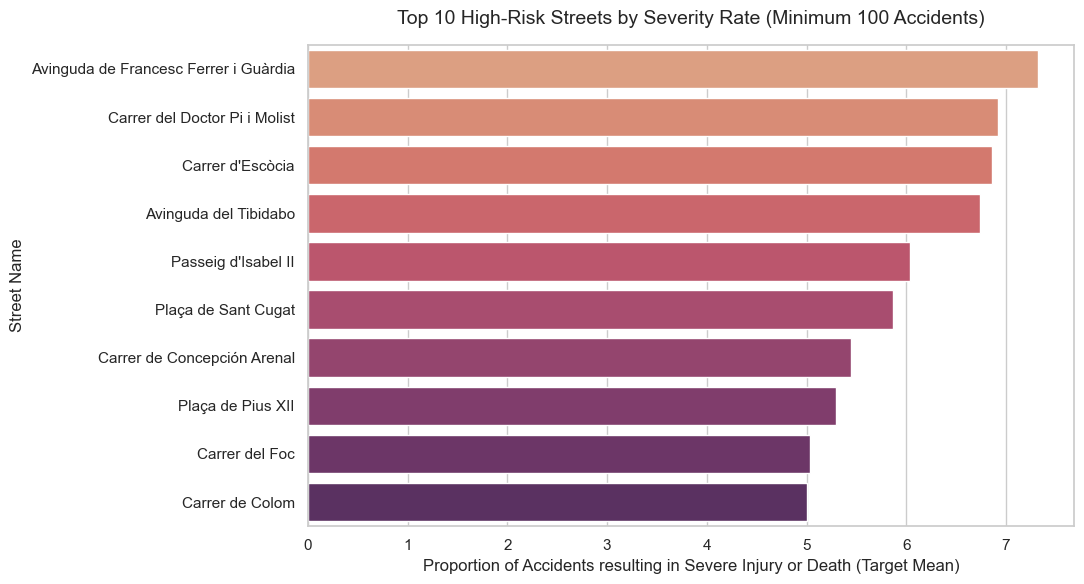

In [9]:
# Grouping by street and filtering for statistical relevance
street_stats = accidents[accidents.location_type =='Single Street'].groupby('official_name_1').agg(
    total_accidents=('num_incident', 'count'),
    severity_rate=('is_severe', 'mean')
).reset_index()

street_stats['severity_rate'] = street_stats['severity_rate']*100

# Filter: Street must have at least 50 accidents to evaluate severity fairly
volume_threshold = 100
significant_streets = street_stats[street_stats['total_accidents'] >= volume_threshold]

# Extract Top 10 streets by severe crash concentration
top_n =10
top_dangerous_streets = significant_streets.sort_values(by='severity_rate', ascending=False).head(top_n)

plt.figure(figsize=(11, 6))
sns.barplot(data=top_dangerous_streets, x='severity_rate', y='official_name_1', hue='official_name_1', legend=False, palette='flare')
plt.title(f'Top {top_n} High-Risk Streets by Severity Rate (Minimum {volume_threshold} Accidents)', pad=15)
plt.xlabel('Proportion of Accidents resulting in Severe Injury or Death (Target Mean)')
plt.ylabel('Street Name')
plt.tight_layout()
plt.show()

> Streets with the higher severity index are not the main streets. These streets are roads like Ronda del Mig  (and it suggests high speed crushes) and/or secondary roads (what means after works late night incidents).

> My next question is: Are these streets responsible for a big number of accidents or just a few ones that happen to be of gave consequences? I will compare their total accidents against streets over the volume threshold using the percentiles

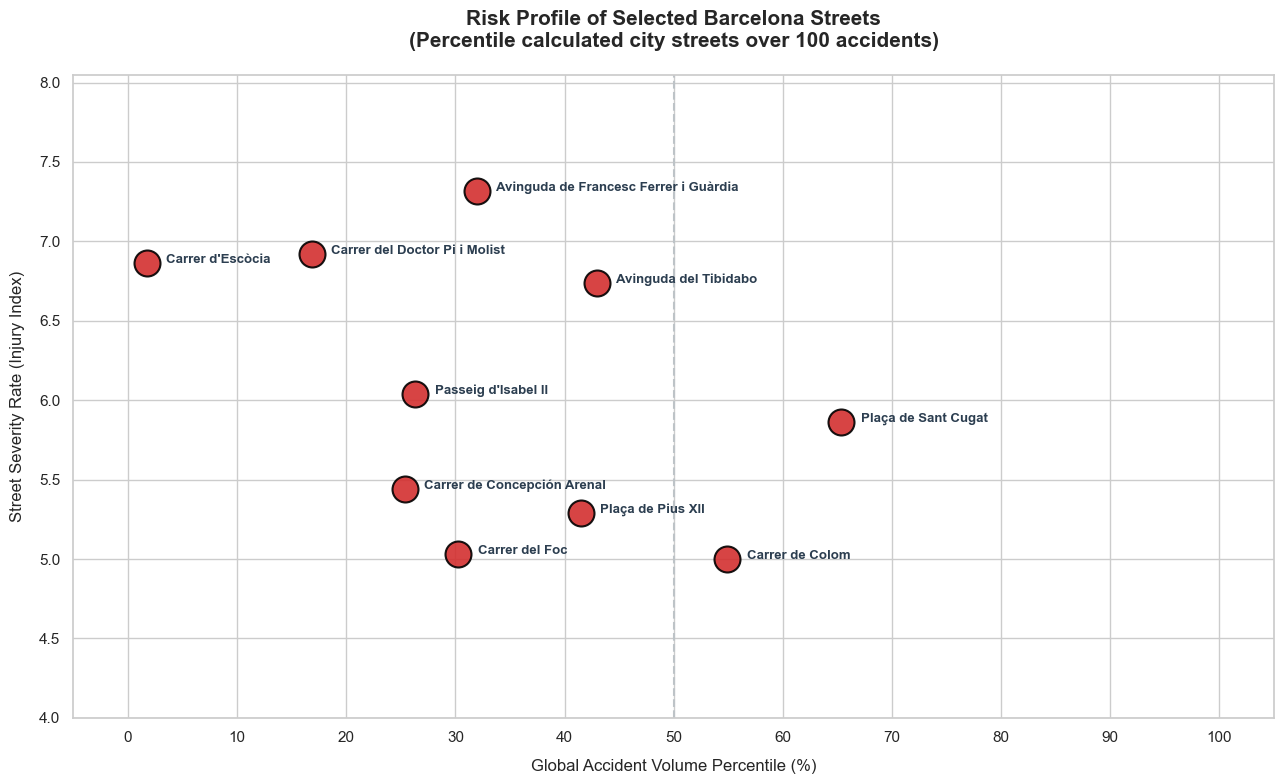

In [10]:
df_all_streets = accidents[accidents.location_type =='Single Street'].groupby('official_name_1').agg(
            total_accidents = ('num_incident','count'),
            severity_rate = ('is_severe','mean')
).reset_index()

df_all_streets['severity_rate'] = df_all_streets['severity_rate']*100
df_all_streets =  df_all_streets[df_all_streets['total_accidents'] >volume_threshold]


# CRITICAL STEP: Compute percentile relative to ALL streets in the city
df_all_streets['total_accidents_percentile'] = df_all_streets['total_accidents'].rank(pct=True) * 100


# ==========================================
# 2. FILTER TO THE TOP 10 RISKIEST STREETS
# ==========================================

# Sort them by severity rate to find the top 10 riskiest profiles
if 'total_accidents_percentile' not in top_dangerous_streets:
    top_dangerous_streets = pd.merge(top_dangerous_streets, df_all_streets[['official_name_1','total_accidents_percentile']],
            how='left',on ='official_name_1')
top_dangerous_streets = top_dangerous_streets.sort_values(by='severity_rate', ascending=False).head(10)


# ==========================================
# 3. VISUALIZE VIA RISK MATRIX
# ==========================================
plt.figure(figsize=(13, 8))
sns.set_theme(style="whitegrid")

# Draw the scatter plot using the computed global percentile
ax = sns.scatterplot(
    x='total_accidents_percentile', 
    y='severity_rate', 
    data=top_dangerous_streets, 
    s=350, 
    color='#D32F2F', # Crimson Risk Color
    edgecolor='black',
    linewidth=1.5,
    alpha=0.9
)

# Annotate street names precisely next to their markers
for i in range(top_dangerous_streets.shape[0]):
    plt.text(
        x=top_dangerous_streets['total_accidents_percentile'].iloc[i] + 1.8, 
        y=top_dangerous_streets['severity_rate'].iloc[i], 
        s=top_dangerous_streets['official_name_1'].iloc[i], 
        fontsize=9.5, 
        weight='bold',
        color='#2C3E50'
    )

# Visual references: Quadrant separators based on theoretical city baselines
plt.axvline(x=50, color='#BDC3C7', linestyle='--', linewidth=1.5, label='City Median Volume (50th Pct)')
plt.axhline(y=df_all_streets['severity_rate'].median(), color='#BDC3C7', linestyle=':', linewidth=1.5, label='City Median Severity')

# Format axes to represent a complete statistical profile
plt.title(f'Risk Profile of Selected Barcelona Streets\n(Percentile calculated city streets over {volume_threshold} accidents)', fontsize=15, pad=20, weight='bold')
plt.xlabel('Global Accident Volume Percentile (%)', fontsize=12, labelpad=10)
plt.ylabel('Street Severity Rate (Injury Index)', fontsize=12, labelpad=10)

plt.xlim(-5, 105) # Padding so 0% and 100% don't clip off the graph edge
plt.ylim(4, top_dangerous_streets['severity_rate'].max() * 1.1)
plt.xticks(range(0, 101, 10)) # Crisp 10% interval marks

plt.tight_layout()
plt.savefig('barcelona_global_street_risk.png', dpi=300)
plt.show()



> Not all street with the highest severity rate are the ones wth more accidenta. They move from a 3% to a 68% approx.

> Let's investigate the streets with more accidents .


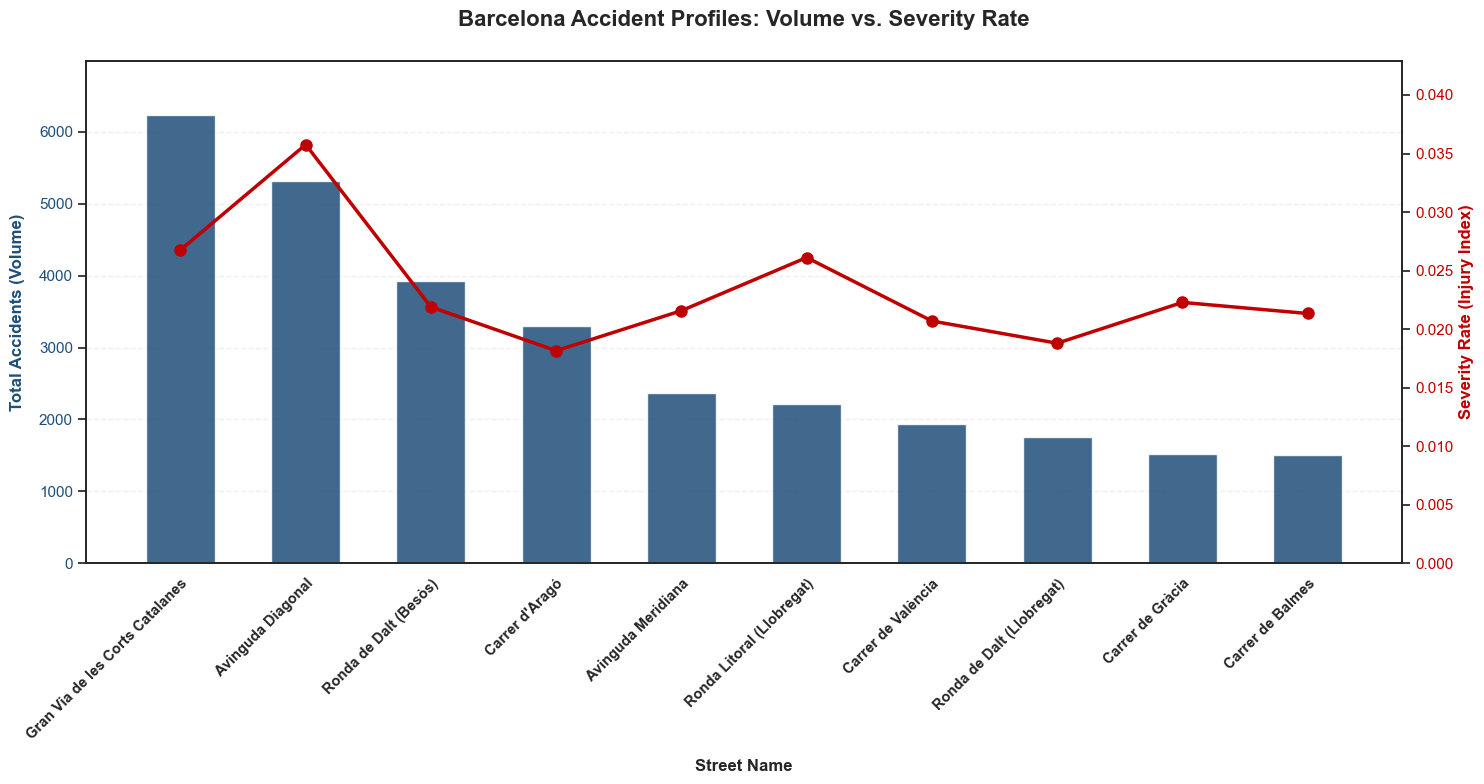

In [11]:
streets_df = accidents[accidents.location_type =='Single Street'].groupby('official_name_1').agg(
            total_accidents = ('num_incident','count'),
            severity_rate = ('is_severe','mean')

).reset_index()
streets_df = streets_df.sort_values('total_accidents',ascending=False).head(10)

# 2. Set up the figure background and fonts
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(15, 8))

# 3. Draw the Primary Axis: Bars for Total Accidents
color_bars = '#1F4E79' # Clean slate blue
bars = ax1.bar(streets_df['official_name_1'], streets_df['total_accidents'], color=color_bars, alpha=0.85, width=0.55, label='Total Accidents')

# # Styling the primary axis
ax1.set_xlabel('Street Name', fontsize=12, labelpad=12, fontweight='bold')
ax1.set_ylabel('Total Accidents (Volume)', color=color_bars, fontsize=12, fontweight='bold',labelpad=10)
ax1.tick_params(axis='y', labelcolor=color_bars)
# ax1.set_xticklabels(streets_df['official_name_1'], rotation=30, ha='right', fontsize=10)
ax1.set_ylim(0, streets_df['total_accidents'].max() * 1.12)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
# # Add numeric labels inside the bars
# for bar in bars:
#     height = bar.get_height()
#     ax1.text(
#         bar.get_x() + bar.get_width()/2., 
#         height + (streets_df['total_accidents'].max() * 0.015),
#         f'{int(height)}',
#         ha='center', va='bottom', color=color_bars, fontweight='bold', fontsize=10
#     )


# 4. Draw the Secondary Axis: Line for Severity Rate
ax2 = ax1.twinx()  # Create the shared x-axis
color_line = '#C00000' # Warning red
ax2.plot(streets_df['official_name_1'], streets_df['severity_rate'], color=color_line, marker='o', linewidth=2.5, markersize=8, label='Severity Rate')

# Styling the secondary axis
ax2.set_ylabel('Severity Rate (Injury Index)', color=color_line, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, streets_df['severity_rate'].max() * 1.2) # Leave space above the highest marker

# Add numeric labels directly above the line markers
# for i, val in enumerate(streets_df['severity_rate']):
#     ax2.text(i+0.2, val+0.001, f"{val:.4f}", ha='center', color=color_line, fontweight='bold', fontsize=15)


ax1.set_xticks(range(len(streets_df))) 
ax1.set_xticklabels(
    streets_df['official_name_1'], 
    rotation=45,          # Steep angle stops text collisions 
    ha='right',           # Anchors the right edge of the text directly beneath the bar ticks
    rotation_mode='anchor',
    fontsize=10.5,
    fontweight='semibold'
)


# 6. Title and Layout adjustments
plt.title('Barcelona Accident Profiles: Volume vs. Severity Rate', fontsize=16, pad=25, fontweight='bold')

# Automatically expands bottom canvas margins so long strings do not get clipped
fig.tight_layout()

# Save image file
plt.savefig('vertical_long_name_chart.png', dpi=300)
plt.show()


> Amongst the top streets, Avinguda Diagonal and Ronda Litoral and Gran Via have the highest severity rate suggesting High Volume that migh need to be monitored.

## 4. **Intersections**

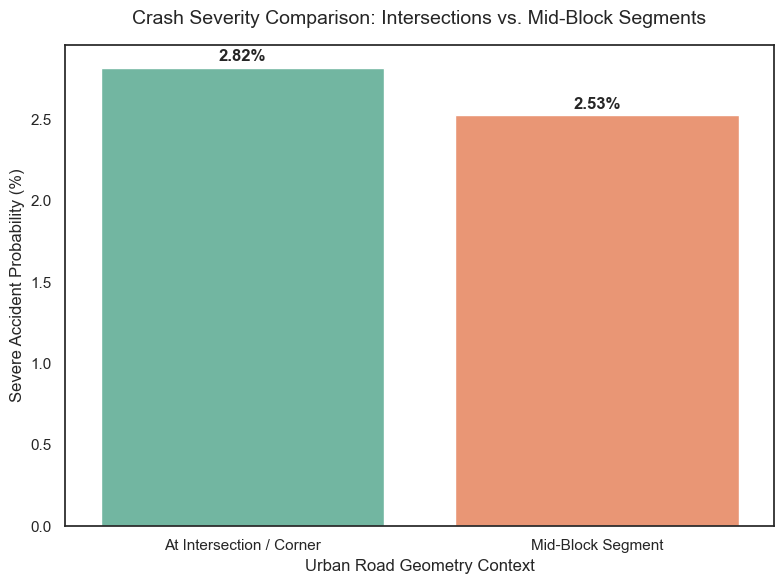

In [13]:
location_split = accidents.groupby('location_type').agg(
        total_accidents =('num_incident', 'count'),
        severity_rate = ('is_severe','mean'),    
).reset_index()
location_split['severity_pct'] = location_split['severity_rate'] * 100
location_split['Location_context'] = np.where(location_split['location_type'] == 'Crossroad', 'At Intersection / Corner', 'Mid-Block Segment')

fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=location_split,
    x='Location_context',
    y='severity_pct',
    hue = 'Location_context',
    palette='Set2',
    legend = False,
    ax=ax1
)

ax1.set_title("Crash Severity Comparison: Intersections vs. Mid-Block Segments", fontsize=14, pad=15)
ax1.set_xlabel("Urban Road Geometry Context", fontsize=12)
ax1.set_ylabel("Severe Accident Probability (%)", fontsize=12)

# Label the exact percentages directly over the bars
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points', weight='bold')

plt.tight_layout()
plt.savefig('intersection_vs_midblock_severity.png', dpi=300)
plt.show()

In [14]:
accidents.location_type.value_counts(normalize=True)

location_type
Single Street    0.844665
Crossroad        0.155335
Name: proportion, dtype: float64

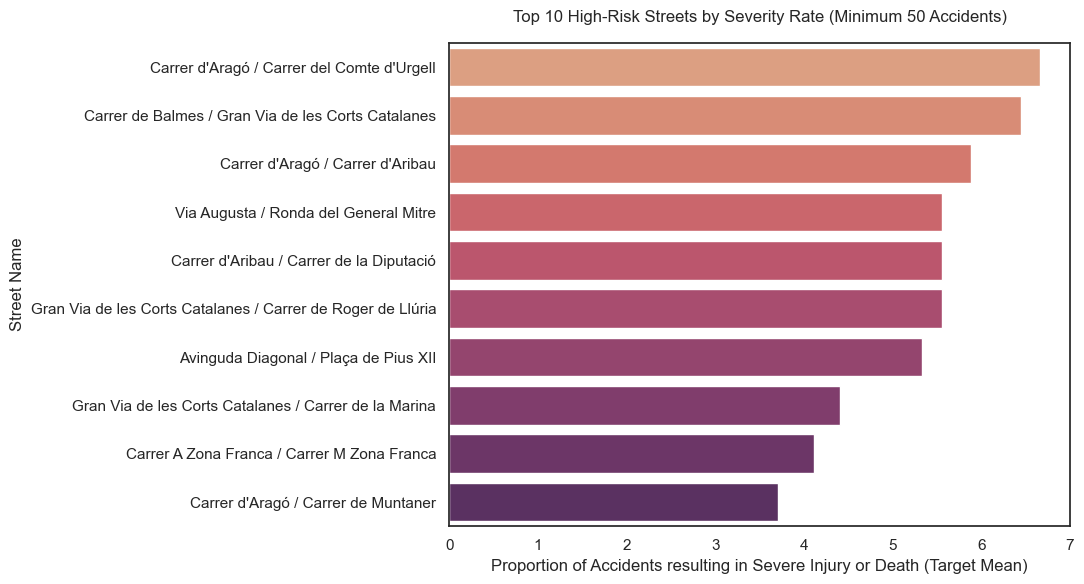

In [15]:
# Grouping by street and filtering for statistical relevance
crossing_stats = accidents[accidents.location_type !='Single Street'].groupby(['id_intersection','intersection_name']).agg(
    total_accidents=('num_incident', 'count'),
    severity_rate=('is_severe', 'mean')
).reset_index()

crossing_stats['severity_rate'] = crossing_stats['severity_rate']*100
# Filter: Street must have at least 50 accidents to evaluate severity fairly
volume_threshold = 50
dangerous_crossings = crossing_stats[crossing_stats['total_accidents'] >= volume_threshold]

# Extract Top 10 streets by severe crash concentration
top_n =10
top_dangerous_crossings = dangerous_crossings.sort_values(by='severity_rate', ascending=False).head(top_n)

plt.figure(figsize=(11, 6))
sns.barplot(data=top_dangerous_crossings, x='severity_rate', y='intersection_name', hue='intersection_name', legend=False, palette='flare')
plt.title(f'Top {top_n} High-Risk Streets by Severity Rate (Minimum {volume_threshold} Accidents)', pad=15)
plt.xlabel('Proportion of Accidents resulting in Severe Injury or Death (Target Mean)')
plt.ylabel('Street Name')
plt.tight_layout()
plt.show()

In [17]:
# Streets with more apperances in intersecttion
df = pd.DataFrame()
total_list = accidents[accidents.location_type !='Single Street'].official_name_1.tolist() +accidents[accidents.location_type !='Single Street'].official_name_2.tolist()
df['street_name'] = total_list
df.street_name.value_counts().iloc[:10]

street_name
Gran Via de les Corts Catalanes    1725
Avinguda Diagonal                  1659
Carrer d'Aragó                     1514
Carrer de València                  927
Carrer de Mallorca                  740
Carrer de Gràcia                    686
Carrer de Balmes                    617
Avinguda Meridiana                  589
Carrer del Consell de Cent          570
Carrer de la Diputació              553
Name: count, dtype: int64

> Intersections are riskier compare to streets.

> Most dangerous crossings, except for one in Mercabarna, include an important street 


# Summary:
### *Accidents, Deaths, victims and target*.
1. District Analysis (Volume vs Rate)

> Eixample: This is the district with the highest number of accidents. It is well explained by containing the most important grid network of streets and crossings.

> Anomalies: Les Corts is an anomaly although the number of accidents is not high when highlighting the severity rate. Sant Marti and Horta_guinardo reperesent a mif d point where accidents ocurr and the rate is high.

2. Neighborhoods.
   
> Observation: top neighborhoods by severyty rate are not in L'Eixample. Even if yoy filter for Q1 only it does not make it in the top 5.

> Insight: Severity rate is higher in neighborhoods around important arteries.

3. Streets

> Observation: Filtering for streets with more than 100 accidents, the top 10 are not any main street.


4. Intersections.

> Observation: Severity Rate is higher for intersections compared to streets. Interesections are only 15% of the accidents registered.

> Insight: It is verty likely that the accidents ocurring in an intersection include a relevant street

